In [47]:
import mne 
from mne.datasets import eegbci

subjects = [1,2,3,4,5]
runs = [6,10,14] 

#cada participante tem 14 runs, porem vou utilizar apenas 3 runs
#run 6 = imaginação do movimento
#run 10 = imaginação
#run 10= imaginação

for subject in subjects:
    file = eegbci.load_data(subject, runs)
raw = mne.io.read_raw_edf(file[0], preload=True)
raw.plot
raw.filter(7,30)


Extracting EDF parameters from /root/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S005/S005R06.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 7 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 7.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 6.00 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 265 samples (1.656 s)



<RawEDF | S005R06.edf, 64 x 19680 (123.0 s), ~9.7 MiB, data loaded>

In [48]:
events, event_id = mne.events_from_annotations(raw)
    
epoch = mne.Epochs(
    raw,
    events,
    event_id,
    tmin=0,
    tmax=4,
    baseline=None,
    preload=True
    )

Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 641 original time points ...
0 bad epochs dropped


In [49]:
psd = epoch.compute_psd(fmin=8, fmax=30)

x = psd.get_data()#feature
y = epoch.events[:, -1]#label

x = x.reshape(len(x), -1)

    Using multitaper spectrum estimation with 7 DPSS windows


In [50]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x,y)

model = RandomForestClassifier()
model.fit(x_train, y_train)

acc = model.score(x_test, y_test)

print("Accuracy", acc)


Accuracy 0.25


Com o dado de apenas 1 participante a accuracia é de 50% ou seja, aleatoridade

Com 5 participantes e runs[6, 10, 14] acc é de 75%

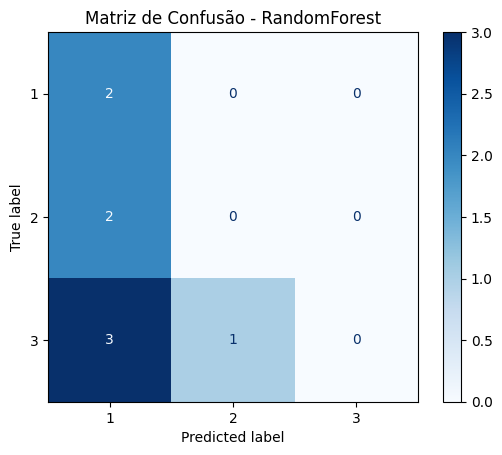

In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusão - RandomForest")
plt.show()